# Clasificación de Tumores Cerebrales mediante Transfer Learning
###  Marco Adrián Vidaurre Soguero

**Objetivo:** Desarrollar un modelo de Deep Learning capaz de clasificar imágenes de resonancia magnética en 4 clases:
* Glioma
* Meningioma
* No Tumor
* Pituitary

**Estrategia Técnica:**
1.  **Arquitectura:** Uso de `DenseNet121` pre-entrenada en ImageNet como extractor de características, se ha elegido este debido a su eficiencia y capacidad para reutilizar características.
2.  **Manejo de Desbalanceo:** Cálculo de pesos de clase (`class_weights`), siendo la Glioma la más difícil de detectar.
3.  **Aumentación Específica:** Enfoque en `RandomContrast` y `RandomBrightness` para detectar texturas difusas, evitando rotaciones agresivas que confunden la anatomía.
4.  **Entrenamiento en dos fases:** "Warm-up" de la cabecera y "Fine-Tuning" de los últimos bloques convolucionales.

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report # Nombre correcto
from sklearn.utils import class_weight
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.densenet import preprocess_input

# Rutas del dataset
base_path = '/kaggle/input/brain-tumor-classification-mri'
train_dir = os.path.join(base_path, 'Training')
test_dir = os.path.join(base_path, 'Testing')

print("Librerías importadas correctamente")

Librerías importadas correctamente


## Carga de datos y creación de test_ds
**Nota:** Para el conjunto de **Test**, usamos `shuffle=False`. Esto es crucial para que al final, cuando generemos la matriz de confusión, las etiquetas reales y las predicciones estén en el mismo orden y no obtengamos resultados aleatorios.

In [38]:
# Configuración básica
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Dataset de Entrenamiento
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Dataset de Validación
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Dataset de Test
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

# Guardar los nombres de las clases antes de optimizar
class_names = train_ds.class_names
print(f"Clases detectadas y guardadas: {class_names}")

# Optimización de rendimiento
# .cache() mantiene las imágenes en memoria tras la primera época
# .prefetch() prepara el siguiente batch mientras la GPU procesa el actual
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 2870 files belonging to 4 classes.
Using 2296 files for training.
Found 2870 files belonging to 4 classes.
Using 574 files for validation.
Found 394 files belonging to 4 classes.
Clases detectadas y guardadas: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


## Cálculo de los pesos de las clases
**Problema encontrado:** El Glioma es la clase más difícil y el modelo tiende a ignorarla para minimizar el error global.

In [39]:
# Extraer las etiquetas de todo el dataset
y_train = []
for images, labels in train_ds.unbatch():
    y_train.append(np.argmax(labels.numpy()))

# Calcular los pesos automáticamente
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Creación del diccionario que pide el modelo
class_weights_dict = dict(enumerate(weights))

for i, name in enumerate(class_names):
    print(f"{name}: {class_weights_dict[i]:.2f}")

glioma_tumor: 0.87
meningioma_tumor: 0.88
no_tumor: 1.82
pituitary_tumor: 0.87


## Definición del modelo
Usamos una arquitectura personalizada basada en **DenseNet121**.
* **Data Augmentation:** Se prioriza `RandomContrast` y `RandomBrightness` para mejorar la detección de texturas sutiles. Al variar la iluminación, enseñamos a la red a distinguir "manchas" oscuras (tumor) de sombras normales, esto se hizo especialmente para aumentar el acierto del diagnóstico de Gliomas. 
* **Backbone:** DenseNet121 (congelado inicialmente).
* **Head (Clasificador):** GlobalAveragePooling -> Dense(512) -> Dropout(0.5) -> Softmax.

In [40]:
def create_optimized_model(num_classes=4):
    # DenseNet121, útil para capturar texturas finas
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False 
    
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.2),
        
        layers.Rescaling(1./255),
        base_model,
        
        # Head
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # Compilación con Label Smoothing
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    return model

model = create_optimized_model()
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_4 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_4 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_4               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,700,804 (29.38 MB)

 Trainable params: 660,228 (2.52 MB)

 Non-trainable params: 7,040,576 (26.86 MB)

## Primer entrenamiento (Transfer Learning Base)

In [41]:
# Callbacks
checkpoint = ModelCheckpoint('best_tumor_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

print("--- Iniciando Entrenamiento Base ---")
history_base = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint, early_stop, reduce_lr],
    class_weight=class_weights_dict
)

--- Iniciando Entrenamiento Base ---
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 276ms/step - accuracy: 0.5940 - auc: 0.8236 - loss: 1.2888 - val_accuracy: 0.7334 - val_auc: 0.9263 - val_loss: 0.8290 - learning_rate: 0.0010
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 202ms/step - accuracy: 0.7812 - auc: 0.9396 - loss: 0.8328 - val_accuracy: 0.7404 - val_auc: 0.9210 - val_loss: 0.8691 - learning_rate: 0.0010
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 200ms/step - accuracy: 0.8071 - auc: 0.9510 - loss: 0.7768 - val_accuracy: 0.7735 - val_auc: 0.9408 - val_loss: 0.8048 - learning_rate: 0.0010
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 200ms/step - accuracy: 0.8167 - auc: 0.9622 - loss: 0.7114 - val_accuracy: 0.8240 - val_auc: 0.9581 - val_loss: 0.7294 - learning_rate: 0.0010
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 201ms/step - accuracy: 0.8580 - auc: 0.9686 - loss: 0.6746 - val_accuracy: 0.8380 - val_auc: 0.9707 - val_loss: 0.6658 - learning_rate: 0.0010
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 

## Segundo entrenamiento: Fine-Tunning
Descongelamos solo las últimas **40 capas**, ya que Es el tamaño aproximado del último bloque denso. No queremos re-entrenar la detección de formas básicas (bordes, curvas), solo la detección de **texturas complejas** (diferencia entre tejido sano y Glioma infiltrado).
* **LR:** Usamos el estándar `1e-5`.

In [42]:
# Buscamos la capa base
base_model = None
for layer in model.layers:
    if 'densenet' in layer.name.lower():
        base_model = layer
        break

if base_model:
    base_model.trainable = True
    for layer in base_model.layers[:-40]:  # Descongelar 40 capas
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 1e-5 para máxima precisión
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
# Re-entrenar
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[checkpoint, early_stop],
    class_weight=class_weights_dict
)

Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 262ms/step - accuracy: 0.9052 - auc: 0.9847 - loss: 0.3024 - val_accuracy: 0.8589 - val_auc: 0.9757 - val_loss: 0.3781
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 212ms/step - accuracy: 0.9150 - auc: 0.9889 - loss: 0.2762 - val_accuracy: 0.8554 - val_auc: 0.9757 - val_loss: 0.3760
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 205ms/step - accuracy: 0.8934 - auc: 0.9869 - loss: 0.2837 - val_accuracy: 0.8606 - val_auc: 0.9752 - val_loss: 0.3772
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 200ms/step - accuracy: 0.8974 - auc: 0.9872 - loss: 0.2722 - val_accuracy: 0.8571 - val_auc: 0.9760 - val_loss: 0.3699
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 195ms/step - accuracy: 0.9072 - auc: 0.9892 - loss: 0.2604 - val_accuracy: 0.8589 - val_auc: 0.9759 - val_loss: 0.3706
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 198ms/step - accuracy: 0.9117 - auc: 0.9905 - loss: 0.2504 - val_accuracy: 0.8589 - val_auc: 0.9765 - val_loss: 0.3671
Epoch 7/15
72/72 ━━━━━━━━━━━━━━━━━

## Visualización de las Curvas de Aprendizaje
Unimos los historiales para ver el impacto del Fine-Tuning. La línea roja marca el punto donde desbloqueamos las capas profundas.

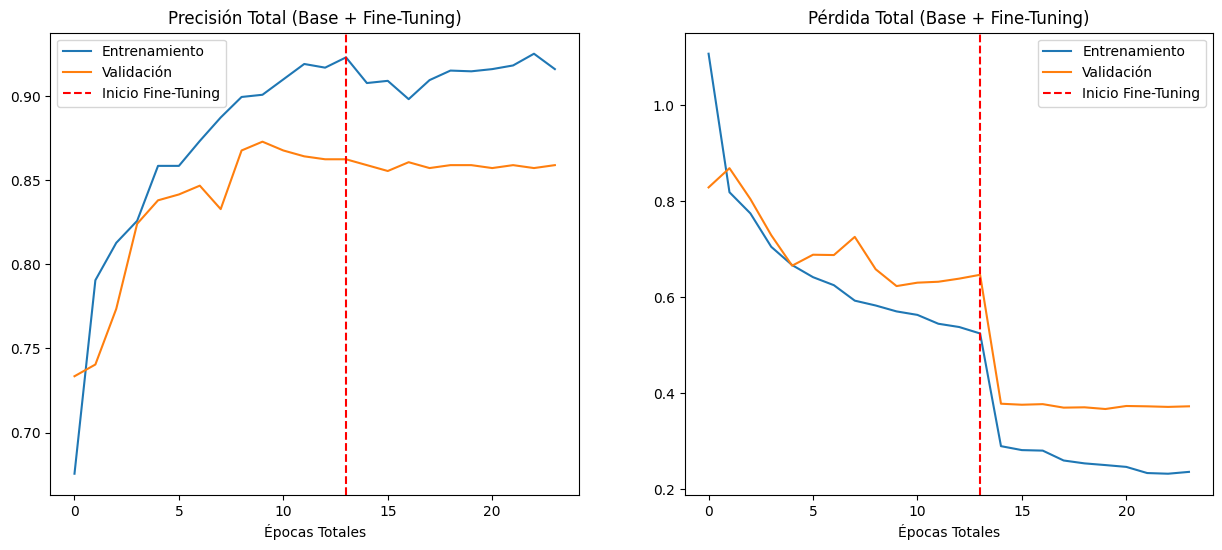

In [43]:
def plot_full_history(h_base, h_fine):
    # Unir los datos de ambas fases
    acc = h_base.history['accuracy'] + h_fine.history['accuracy']
    val_acc = h_base.history['val_accuracy'] + h_fine.history['val_accuracy']
    loss = h_base.history['loss'] + h_fine.history['loss']
    val_loss = h_base.history['val_loss'] + h_fine.history['val_loss']
    
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 6))
    
    # Gráfica de Precisión
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Entrenamiento')
    plt.plot(epochs_range, val_acc, label='Validación')
    # Dibujar una línea donde empezó el Fine-Tuning para que se vea el salto
    plt.axvline(x=len(h_base.history['accuracy'])-1, color='red', linestyle='--', label='Inicio Fine-Tuning')
    plt.title('Precisión Total (Base + Fine-Tuning)')
    plt.xlabel('Épocas Totales')
    plt.legend()

    # Gráfica de Pérdida
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Entrenamiento')
    plt.plot(epochs_range, val_loss, label='Validación')
    plt.axvline(x=len(h_base.history['accuracy'])-1, color='red', linestyle='--', label='Inicio Fine-Tuning')
    plt.title('Pérdida Total (Base + Fine-Tuning)')
    plt.xlabel('Épocas Totales')
    plt.legend()
    
    plt.show()

plot_full_history(history_base, history_fine)

## Evaluación Final con el Dataset de Test
Evaluamos el modelo cargado (`best_tumor_model.keras`) sobre el set de Test. La matriz de confusión nos confirmará si la estrategia ha logrado reducir los falsos negativos en la columna de **Glioma**.

In [44]:
model = load_model(
    'best_tumor_model.keras',
    custom_objects={'preprocess_input': preprocess_input}
)

# Evaluar en el dataset de prueba
results = model.evaluate(test_ds)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")
print(f"Test AUC: {results[2]:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.5418 - auc: 0.7354 - loss: 1.4721
Test Loss: 1.0405
Test Accuracy: 0.7005
Test AUC: 0.8790


Generando predicciones sobre dataset de prueba...


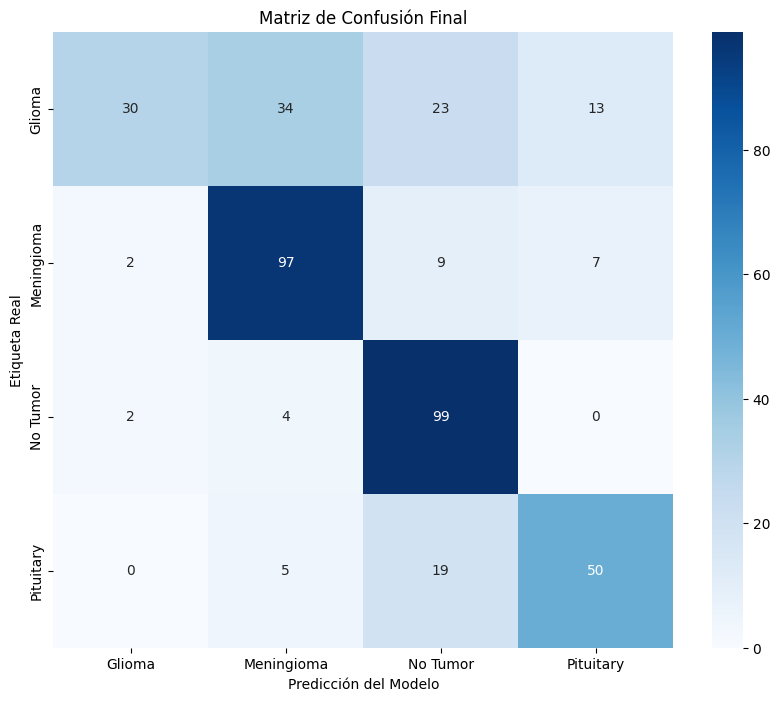

              precision    recall  f1-score   support

      Glioma       0.88      0.30      0.45       100
  Meningioma       0.69      0.84      0.76       115
    No Tumor       0.66      0.94      0.78       105
   Pituitary       0.71      0.68      0.69        74

    accuracy                           0.70       394
   macro avg       0.74      0.69      0.67       394
weighted avg       0.74      0.70      0.67       394



In [45]:
# Definir nombres manualmente para evitar errores
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

y_true = []
y_pred = []

print("Generando predicciones sobre dataset de prueba...")
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Matriz de Confusión
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Matriz de Confusión Final')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

## Conclusiones
Como se puede apreciar, donde más falla el modelo es en Glioma, el cual lo confunde con el resto, seguido de Pituitary. Exceptuando el Glioma, que la precisión rondará en torno al 25 %, se puede notar que el modelo tiene una buena precisión y tiene un buen márgen de mejora.
Como posibles mejoras del modelo, se podrían encontrar las siguientes:

1- Aumentar el peso de forma artificial del Glioma, esto haría que al fallar, se le penalice más severamente al modelo, lo que podría aumentar el porcentaje de precisión.

2- Ajustar los hiperparámetros, un learning rate más bajo durante fine tuning, early stopping más agresivo o regularización L2 y Dropout.

3- Usar otro modelo preentrenado como MobileNetV2 o ResNet50.

4- Cambiar el enfoque y por tanto el tipo de problema planteado, ya sea como clasificación binaria (tumor/no tumor) o clasificaciones jerárquicas (tumor vs tipo de tumor).

El enfoque es correcto y bien estructurado, pero el rendimiento está limitado principalmente por el desbalance del dataset y la dificultad intrínseca del problema. Con las mejoras propuestas, el modelo podría aumentar significativamente su utilidad práctica.